# 09 — Backtesting & Validation Framework

Phase 9 of the Indian Equity AI project plan.

Runs the Phase 5-style technical classifier through walk-forward folds (with an
embargo between train and test to prevent 1-day-ahead label overlap), simulates
trading the resulting signals with transaction costs and slippage, and compares
the result against a NIFTY 50 buy & hold benchmark over the same period.

**H6:** does any predictive edge survive realistic transaction costs and slippage?

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
from lightgbm import LGBMClassifier

from src.ingestion.market_data import download_index_ohlcv
from src.preprocessing.clean import clean_ohlcv
from src.features.returns import add_returns as add_index_returns
from src.models.dataset import FEATURE_COLUMNS, add_next_day_return, add_target, build_feature_table
from src.models.walkforward import expanding_window_folds
from src.backtesting.engine import aggregate_portfolio_returns, simulate_trades
from src.backtesting.metrics import (
    annualized_return, calmar_ratio, cumulative_return, max_drawdown_from_returns,
    profit_factor, sharpe_ratio, sortino_ratio, turnover, win_rate,
)

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
RANDOM_STATE = 42
SIGNAL_THRESHOLD = 0.55


def make_lgbm():
    return LGBMClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE, verbose=-1,
    )

## Step 1: Build the dataset (features + direction target + continuous return target)

In [2]:
technical = pd.read_parquet(DATA_PROCESSED / "technical_features.parquet")
df = build_feature_table(technical)
df = add_target(df)
df = add_next_day_return(df)

required = FEATURE_COLUMNS + ["next_day_direction", "next_day_return"]
dataset = df.dropna(subset=required).reset_index(drop=True)
print("Rows:", len(dataset), "| Date range:", dataset["date"].min().date(), "to", dataset["date"].max().date())

Rows: 5205 | Date range: 2022-07-14 to 2026-09-24


## Step 2: Walk-forward folds with a 2-day embargo

The embargo drops the last 2 days before each fold's test window from that fold's
training set -- next_day_direction/return labels are built from the *following*
day's price, so without an embargo the last training row(s) would be labeled
using a price that falls at or inside the test window's boundary.

In [3]:
folds = expanding_window_folds(dataset["date"], n_folds=4, min_train_frac=0.5, embargo_days=2)
for train_end, test_start, test_end in folds:
    print(f"train up to {pd.Timestamp(train_end).date()} | test {pd.Timestamp(test_start).date()} to {pd.Timestamp(test_end).date()}")

train up to 2024-08-22 | test 2024-08-27 to 2025-03-03
train up to 2025-02-27 | test 2025-03-04 to 2025-09-11
train up to 2025-09-09 | test 2025-09-12 to 2026-03-20
train up to 2026-03-18 | test 2026-03-23 to 2026-09-24


## Step 3: Generate out-of-sample probability_up for every fold's test window

In [4]:
oos_rows = []
for train_end, test_start, test_end in folds:
    fold_train = dataset[dataset["date"] <= train_end]
    fold_test = dataset[(dataset["date"] >= test_start) & (dataset["date"] <= test_end)]

    model = make_lgbm()
    model.fit(fold_train[FEATURE_COLUMNS], fold_train["next_day_direction"])
    proba_up = model.predict_proba(fold_test[FEATURE_COLUMNS])[:, 1]

    oos_rows.append(
        fold_test[["date", "symbol", "next_day_return"]].assign(probability_up=proba_up)
    )

oos = pd.concat(oos_rows, ignore_index=True)
print("Out-of-sample rows across all folds:", len(oos))
print("Date range:", oos["date"].min().date(), "to", oos["date"].max().date())

Out-of-sample rows across all folds: 2605
Date range: 2024-08-27 to 2026-09-24


## Step 4: Simulate trades (gross, no costs, vs. net of transaction costs + slippage)

In [5]:
trades_net = simulate_trades(oos, threshold=SIGNAL_THRESHOLD, transaction_cost_bps=10, slippage_bps=5)
trades_gross = simulate_trades(oos, threshold=SIGNAL_THRESHOLD, transaction_cost_bps=0, slippage_bps=0)

portfolio_net = aggregate_portfolio_returns(trades_net)
portfolio_gross = aggregate_portfolio_returns(trades_gross)

print("Trading days in the combined out-of-sample period:", len(portfolio_net))
print("Fraction of (symbol, day) observations with an active signal:", turnover(trades_net["signal"]))

Trading days in the combined out-of-sample period: 521
Fraction of (symbol, day) observations with an active signal: 0.5059500959692899


## Step 5: NIFTY 50 buy & hold benchmark, over the exact same date range

In [6]:
nifty50 = clean_ohlcv(download_index_ohlcv("^NSEI", period="5y"))
nifty50 = add_index_returns(nifty50, periods=(1,))
nifty50 = nifty50.set_index("date")

benchmark_returns = nifty50.loc[nifty50.index.isin(portfolio_net.index), "return_1d"].reindex(
    portfolio_net.index
)
print("Benchmark trading days matched:", benchmark_returns.notna().sum(), "/", len(portfolio_net))
benchmark_returns = benchmark_returns.fillna(0.0)

Benchmark trading days matched: 516 / 521


## Step 6: Compare strategy (gross and net) vs. benchmark

In [7]:
def summarize(returns: pd.Series, trade_returns: pd.Series | None = None, signal: pd.Series | None = None) -> dict:
    summary = {
        "cumulative_return": cumulative_return(returns),
        "annualized_return": annualized_return(returns),
        "sharpe_ratio": sharpe_ratio(returns),
        "sortino_ratio": sortino_ratio(returns),
        "max_drawdown": max_drawdown_from_returns(returns),
        "calmar_ratio": calmar_ratio(returns),
    }
    if trade_returns is not None:
        summary["win_rate"] = win_rate(trade_returns)
        summary["profit_factor"] = profit_factor(trade_returns)
    if signal is not None:
        summary["turnover"] = turnover(signal)
    return summary


active_net = trades_net[trades_net["signal"] == 1]["net_return"]
active_gross = trades_gross[trades_gross["signal"] == 1]["gross_return"]

comparison = pd.DataFrame(
    {
        "strategy_net_of_cost": summarize(portfolio_net, active_net, trades_net["signal"]),
        "strategy_gross": summarize(portfolio_gross, active_gross, trades_gross["signal"]),
        "nifty50_buy_and_hold": summarize(benchmark_returns),
    }
)
comparison

,strategy_net_of_cost,strategy_gross,nifty50_buy_and_hold
cumulative_return,-0.649024,-0.257310,-0.077867
annualized_return,-0.397361,-0.134013,-0.038452
sharpe_ratio,-2.647311,-0.687300,-0.238065
sortino_ratio,-3.771578,-0.986593,-0.353281
max_drawdown,-0.652019,-0.394650,-0.157667
calmar_ratio,-0.609431,-0.339573,-0.243879
win_rate,0.414264,0.471168,NaN
profit_factor,0.654962,0.877940,NaN
turnover,0.505950,0.505950,NaN


## Step 7: Save

In [8]:
comparison.to_csv(DATA_PROCESSED / "backtest_comparison.csv")

equity_curves = pd.DataFrame(
    {
        "strategy_net": (1 + portfolio_net).cumprod(),
        "strategy_gross": (1 + portfolio_gross).cumprod(),
        "nifty50": (1 + benchmark_returns).cumprod(),
    }
)
equity_curves.to_csv(DATA_PROCESSED / "backtest_equity_curves.csv")
print("Saved:", DATA_PROCESSED / "backtest_comparison.csv")
print("Saved:", DATA_PROCESSED / "backtest_equity_curves.csv")

Saved: D:\Practise\Stock Market Analysis\data\processed\backtest_comparison.csv
Saved: D:\Practise\Stock Market Analysis\data\processed\backtest_equity_curves.csv


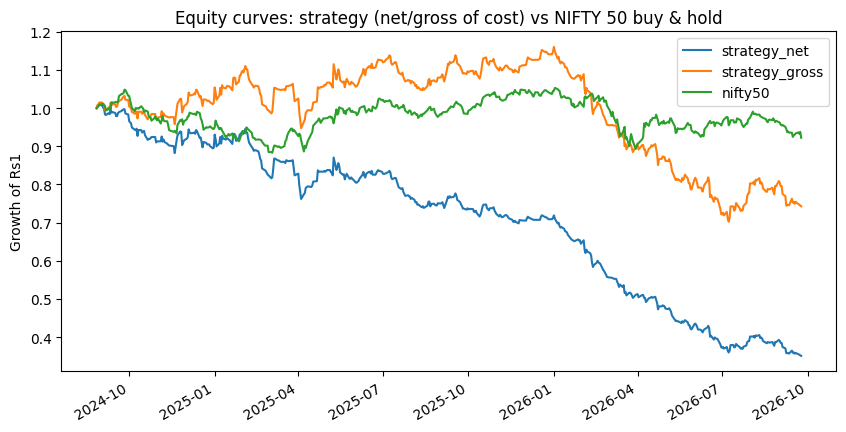

In [9]:
import matplotlib.pyplot as plt

equity_curves.plot(figsize=(10, 5), title="Equity curves: strategy (net/gross of cost) vs NIFTY 50 buy & hold")
plt.ylabel("Growth of Rs1")
plt.show()

## Reflection: H6 -- does any edge survive realistic costs?

Compare `strategy_gross` vs `strategy_net_of_cost` above: the gap between them is
exactly the cost of the ~15bps-per-trade round-trip friction applied to every taken
trade. Then compare both against `nifty50_buy_and_hold`.

Given Phases 5, 7, and 8 consistently found next-day direction ROC-AUC hovering
near 0.50 (no real predictive edge from technical features alone), the honest
expectation here is that the strategy shows **no robust edge even before costs**,
in which case H6 is answered trivially: there was nothing to survive the costs in
the first place. If gross returns do look attractive, the critical question is
whether that holds up net of the ~15bps round-trip cost and slippage above -- and
whether it's not simply an artifact of this specific walk-forward window (a longer
history and more folds would be needed before trusting a positive result here).

This backtest uses a simplified trading convention (enter/exit at close, single-day
hold, equal-weight across active signals) -- see `src/backtesting/engine.py` for
the documented assumptions. It is a research-quality comparison for this project's
stated educational/decision-support purpose, not a production trading simulation.